In [8]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D

In [2]:
(train_data, test_data), info = tfds.load("cats_vs_dogs",split=["train[:80%]", "train[80%:]"],as_supervised=True,with_info=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.3Y19IR_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [3]:
train_data = train_data.map(lambda x, y: (tf.image.resize(x, (64, 64)) / 255.0, y))

In [4]:
train_data

<_MapDataset element_spec=(TensorSpec(shape=(64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [5]:

test_data = test_data.map(lambda x, y: (tf.image.resize(x, (64, 64)) / 255.0, y))

In [6]:
test_data

<_MapDataset element_spec=(TensorSpec(shape=(64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [7]:
train_data = train_data.batch(32)
test_data = test_data.batch(32)

In [9]:
# Take one batch from training data
images, labels = next(iter(train_data))

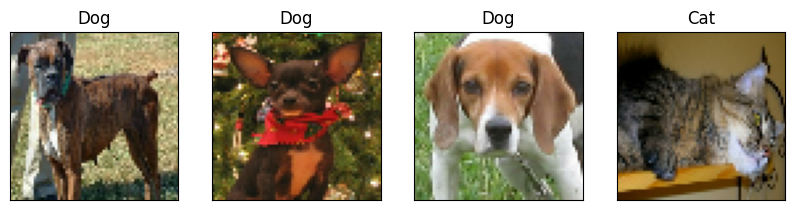

In [10]:

plt.figure(figsize=(10, 4))

# Image 1
plt.subplot(1, 4, 1)
plt.imshow(images[0])
plt.title("Dog" if labels[0] == 1 else "Cat")
plt.xticks([])
plt.yticks([])

# Image 2
plt.subplot(1, 4, 2)
plt.imshow(images[1])
plt.title("Dog" if labels[1] == 1 else "Cat")
plt.xticks([])
plt.yticks([])

# Image 3
plt.subplot(1, 4, 3)
plt.imshow(images[2])
plt.title("Dog" if labels[2] == 1 else "Cat")
plt.xticks([])
plt.yticks([])

# Image 4
plt.subplot(1, 4, 4)
plt.imshow(images[3])
plt.title("Dog" if labels[3] == 1 else "Cat")
plt.xticks([])
plt.yticks([])

plt.show()

In [11]:
model = Sequential()
model.add(Conv2D(16, (3,3), activation='relu', input_shape=(64,64,3)))
model.add(MaxPooling2D(2,2))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [13]:
model.fit(train_data, epochs=5)

Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.5946 - loss: 0.6632
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - accuracy: 0.7271 - loss: 0.5480
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.7604 - loss: 0.4937
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.7895 - loss: 0.4537
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 18s 32ms/step - accuracy: 0.8069 - loss: 0.4226
